In [1]:
import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt

# Phase 1 — Data Prep (Python / pandas)

In [2]:
df = pd.read_csv("../data/chess.csv")

In [3]:
df.head()

,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


In [4]:
df.describe()
df.shape

(20058, 16)

In [5]:
df.isnull().sum()

id                0
rated             0
created_at        0
last_move_at      0
turns             0
victory_status    0
winner            0
increment_code    0
white_id          0
white_rating      0
black_id          0
black_rating      0
moves             0
opening_eco       0
opening_name      0
opening_ply       0
dtype: int64

In [6]:
df['created_at'] = pd.to_datetime(df['created_at'], unit='ms')
df['last_move_at'] = pd.to_datetime(df['last_move_at'], unit='ms')


df[["created_at", "last_move_at"]]

,created_at,last_move_at
0,2017-08-31 20:06:40.000,2017-08-31 20:06:40.000
1,2017-08-30 21:53:20.000,2017-08-30 21:53:20.000
2,2017-08-30 21:53:20.000,2017-08-30 21:53:20.000
3,2017-08-30 16:20:00.000,2017-08-30 16:20:00.000
4,2017-08-29 18:06:40.000,2017-08-29 18:06:40.000
...,...,...
20053,2017-07-11 16:35:14.342,2017-07-11 16:40:36.076
20054,2017-07-10 14:48:09.760,2017-07-10 15:00:33.979
20055,2017-07-10 14:44:37.493,2017-07-10 14:47:30.327
20056,2017-07-10 14:15:27.019,2017-07-10 14:31:13.718


Some rows have same time value for both columns



In [7]:

sametimes_len = (df[df['created_at'] == df['last_move_at']].shape[0])

total_len = df.shape[0]

print(f"Percentage of games where created_at == last_move_at: {sametimes_len/total_len*100:.2f}%")


Percentage of games where created_at == last_move_at: 42.62%


In [8]:
df_diff = df[df['created_at'] != df['last_move_at']]
df_diff.head()


,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
14,u7i6dOaJ,False,2017-08-30 10:46:40,2017-08-30 13:33:20,31,mate,white,15+15,shivangithegenius,1094,sureka_akshat,1141,e4 e5 Nf3 Nc6 Bc4 Nf6 Nc3 Bc5 O-O O-O d3 Ne8 B...,C50,Four Knights Game: Italian Variation,8
43,oqoT4DLS,False,2017-07-09 14:20:00,2017-07-09 17:06:40,66,resign,white,40+40,rajuppi,2443,shivangithegenius,978,e4 c5 Nf3 d6 d4 cxd4 Nxd4 Nf6 Nc3 g6 Be3 Bg7 f...,B76,Sicilian Defense: Dragon Variation | Yugoslav...,17
49,iq3Kz06t,False,2017-06-25 14:13:20,2017-06-25 17:00:00,41,mate,white,40+40,rajuppi,2436,shivangithegenius,978,e4 d5 exd5 Qxd5 Qf3 Qe5+ Ne2 Nf6 d4 Qd5 Qxd5 N...,B01,Scandinavian Defense: Mieses-Kotroc Variation,4
52,KYPdQv8e,False,2017-06-19 16:33:20,2017-06-19 19:20:00,53,mate,white,10+0,shivangithegenius,978,lucasimeon,1500,d4 f5 e3 Nf6 Nc3 d5 Bb5+ c6 Bd3 b5 Qf3 Qa5 Bxf...,A80,Dutch Defense,2
54,PBS4FEld,True,2017-08-20 09:06:40,2017-08-20 11:53:20,8,resign,white,16+0,wing175,1521,gerfsh,1162,Nf3 e5 Nxe5 Ke7 e4 Kd6 d4 Nc6,A04,Zukertort Opening: Ross Gambit,2


In [9]:
df_same = df[df['created_at'] == df['last_move_at']]
df_same[df_same["turns"] > 10]

,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,2017-08-31 20:06:40,2017-08-31 20:06:40,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,2017-08-30 21:53:20,2017-08-30 21:53:20,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,2017-08-30 21:53:20,2017-08-30 21:53:20,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,2017-08-30 16:20:00,2017-08-30 16:20:00,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,2017-08-29 18:06:40,2017-08-29 18:06:40,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9281,rdD9KSfi,False,2016-05-10 03:13:20,2016-05-10 03:13:20,111,resign,white,10+0,vzg100,1588,rei_maior,1500,e4 e5 d4 d6 dxe5 dxe5 Qxd8+ Kxd8 Nf3 Nc6 Bc4 f...,B07,King's Pawn Game: Maroczy Defense,4
9282,DInvwDFc,False,2016-05-10 00:26:40,2016-05-10 00:26:40,49,resign,black,8+0,derek_87,1296,vzg100,1588,e4 e5 Nc3 Nf6 b4 Nc6 a3 d6 d3 h6 h3 d5 exd5 Nx...,C26,Vienna Game: Falkbeer Variation,4
9283,P5uLal64,True,2016-02-22 00:13:20,2016-02-22 00:13:20,70,resign,black,30+0,mikaone,1697,vzg100,1566,e4 e5 Bc4 Nf6 d3 Nc6 Bg5 h6 Bxf6 Qxf6 h3 Bc5 c...,C24,Bishop's Opening: Berlin Defense,4
9284,hSqBGEK8,False,2015-01-28 01:53:20,2015-01-28 01:53:20,38,outoftime,black,5+5,persian_girl,1662,malinna,1586,d4 d5 c4 Nf6 Nf3 Nc6 Nc3 Bg4 h3 Bxf3 gxf3 dxc4...,D06,Queen's Gambit Refused: Marshall Defense,4


the *created_at* and *last_move_at* columns have records with same values. About 43% of records share this characterstic. The first assumption is that maybe these games ended quickly (aborts, resignation etc), but aupon further inspection, there are many records with more than 10 turns some even in 40s and 50s, this means that the first assuimption is wrong.

Most likely case is that these specific matches didn't have this data which is probably because of these matches being very old. Hence, some created_at and last_move_at records have same values

## Prepping the other Columns

C:\Users\BURAIR\AppData\Local\Temp\ipykernel_15848\1613526394.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rated', data=df, palette='Set1')


Text(0.5, 1.0, 'Rated Vs Unrated Games')

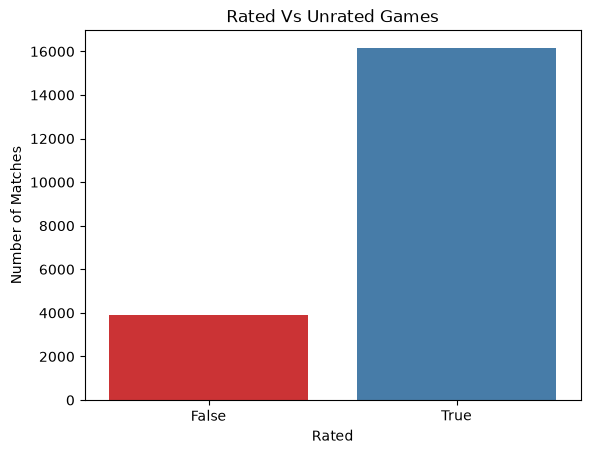

In [10]:
sns.countplot(x='rated', data=df, palette='Set1')
plt.xlabel("Rated")
plt.ylabel("Number of Matches")
plt.title("Rated Vs Unrated Games")

In [11]:
df["increment_code"].head(20)

0      15+2
1      5+10
2      5+10
3      20+0
4      30+3
5      10+0
6      10+0
7     15+30
8      15+0
9      10+0
10    20+60
11    20+60
12     5+40
13      8+0
14    15+15
15    15+15
16    15+15
17    15+16
18    15+15
19     11+0
Name: increment_code, dtype: str

C:\Users\BURAIR\AppData\Local\Temp\ipykernel_15848\1003736177.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


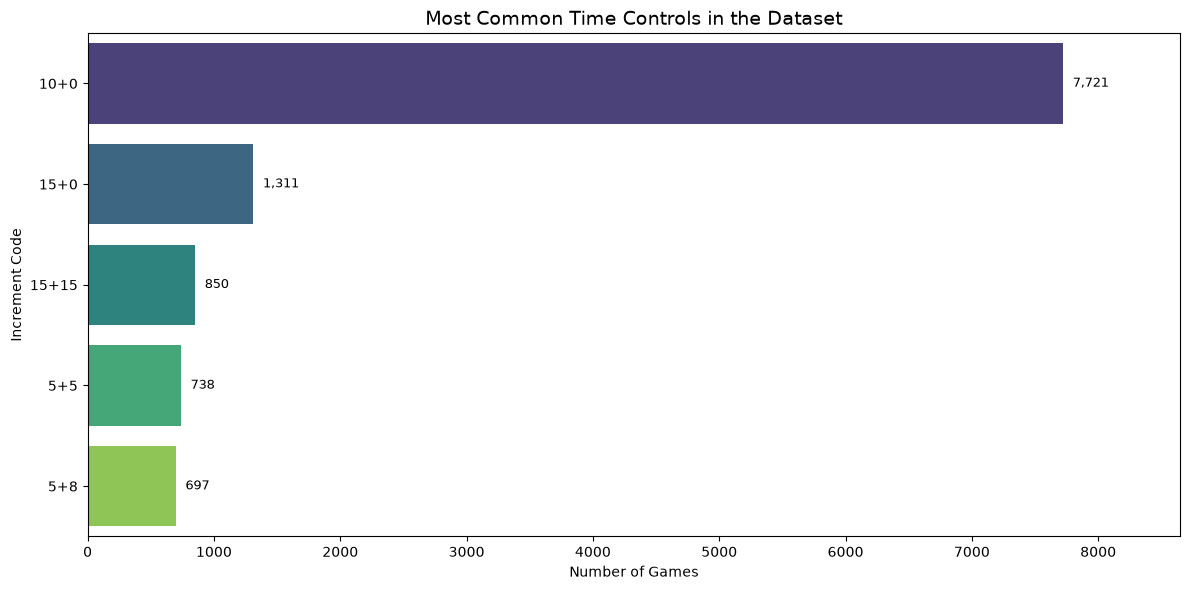

In [12]:
inc_counts = df["increment_code"].value_counts().head()

plt.figure(figsize=(12, 6))
sns.barplot(
    x=inc_counts.values,
    y=inc_counts.index,
    orient="h",
    palette="viridis",
    order=inc_counts.index,
)
plt.title("Most Common Time Controls in the Dataset", fontsize=14)
plt.xlabel("Number of Games")
plt.ylabel("Increment Code")
plt.xlim(0, inc_counts.max() * 1.12)

for i, value in enumerate(inc_counts.values):
    plt.text(value + inc_counts.max() * 0.01, i, f"{value:,}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

In [13]:
split_cols = df["increment_code"].str.split("+", expand = True)

df["base_time"] = split_cols[0].astype(int)
df["increment"] = split_cols[1].astype(int)

df.head()

,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply,base_time,increment
0,TZJHLljE,False,2017-08-31 20:06:40,2017-08-31 20:06:40,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5,15,2
1,l1NXvwaE,True,2017-08-30 21:53:20,2017-08-30 21:53:20,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4,5,10
2,mIICvQHh,True,2017-08-30 21:53:20,2017-08-30 21:53:20,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3,5,10
3,kWKvrqYL,True,2017-08-30 16:20:00,2017-08-30 16:20:00,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3,20,0
4,9tXo1AUZ,True,2017-08-29 18:06:40,2017-08-29 18:06:40,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5,30,3


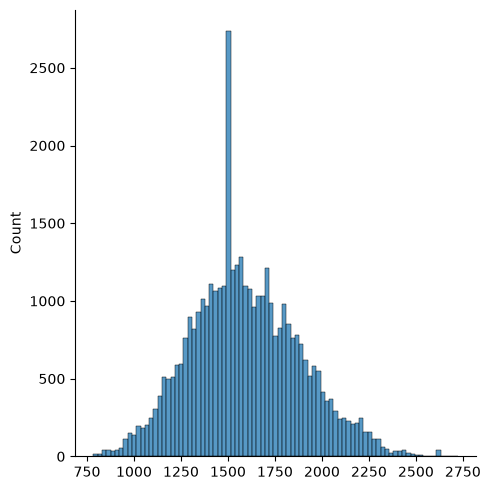

In [14]:
all_ratings = pd.concat([df["white_rating"], df["black_rating"]])
sns.displot(all_ratings)


In [15]:
# preparing rating difference column

df["rating_diff"] = df["white_rating"] - df["black_rating"]

df["rating_diff"].head()

df["rating_diff_abs"] = df["rating_diff"].abs()
df["rating_diff_abs"]

0        309
1         61
2          4
3         15
4         54
        ... 
20053    471
20054     37
20055     67
20056    133
20057    104
Name: rating_diff_abs, Length: 20058, dtype: int64

In [16]:
df["opening_name"].head(30)


0                      Slav Defense: Exchange Variation
1                Nimzowitsch Defense: Kennedy Variation
2                 King's Pawn Game: Leonardis Variation
3                Queen's Pawn Game: Zukertort Variation
4                                      Philidor Defense
5                  Sicilian Defense: Mongoose Variation
6            Blackmar-Diemer Gambit: Pietrowsky Defense
7     Nimzowitsch Defense: Kennedy Variation |  Link...
8                 Italian Game: Schilling-Kostic Gambit
9         Scandinavian Defense: Mieses-Kotroc Variation
10                                 Van't Kruijs Opening
11    French Defense: Advance Variation |  Paulsen A...
12                     French Defense: Knight Variation
13                                    French Defense #2
14                 Four Knights Game: Italian Variation
15    Italian Game: Two Knights Defense |  Knight At...
16                 Four Knights Game: Italian Variation
17                 Four Knights Game: Italian Va

In [17]:
x = df["opening_name"].str.split(":", expand = True, n=1)
df["opening_name"] = x[0]
df["variation"] = x[1]


In [18]:
df["variation"] = df["variation"].str.strip()
df["opening_name"] = df["opening_name"].str.strip()

In [19]:
df["winner"].describe()
df["winner"].isnull()

0        False
1        False
2        False
3        False
4        False
         ...  
20053    False
20054    False
20055    False
20056    False
20057    False
Name: winner, Length: 20058, dtype: bool

In [20]:
df["victory_status"].describe()

count      20058
unique         4
top       resign
freq       11147
Name: victory_status, dtype: object

In [21]:
df["victory_status"].unique()

<StringArray>
['outoftime', 'resign', 'mate', 'draw']
Length: 4, dtype: str

In [22]:
df["victory_status"].isnull()

0        False
1        False
2        False
3        False
4        False
         ...  
20053    False
20054    False
20055    False
20056    False
20057    False
Name: victory_status, Length: 20058, dtype: bool

<Axes: xlabel='victory_status', ylabel='Count'>

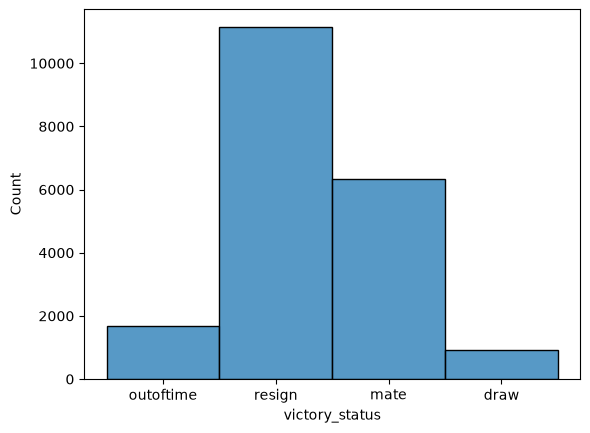

In [23]:
sns.histplot(df["victory_status"])

# Phase 2: EDA

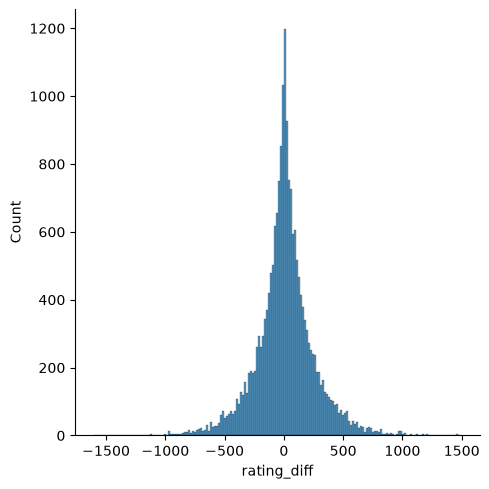

In [24]:
# Plotting the rating_diff distribution to figure out how close typical matchups are.

sns.displot(df["rating_diff"])

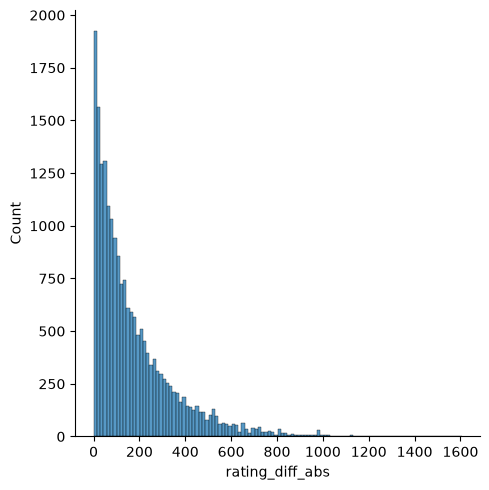

In [25]:
sns.displot(df["rating_diff_abs"])

In [26]:
df["rating_diff"].describe()

count    20058.000000
mean         7.799880
std        249.036667
min      -1605.000000
25%       -108.000000
50%          3.000000
75%        122.000000
max       1499.000000
Name: rating_diff, dtype: float64

In [27]:
rating_diff_bins = pd.qcut(df["rating_diff_abs"], q=5)

rating_diff_bins

0        (284.0, 1605.0]
1           (34.0, 83.0]
2         (-0.001, 34.0]
3         (-0.001, 34.0]
4           (34.0, 83.0]
              ...       
20053    (284.0, 1605.0]
20054       (34.0, 83.0]
20055       (34.0, 83.0]
20056      (83.0, 156.0]
20057      (83.0, 156.0]
Name: rating_diff_abs, Length: 20058, dtype: category
Categories (5, interval[float64, right]): [(-0.001, 34.0] < (34.0, 83.0] < (83.0, 156.0] < (156.0, 284.0] < (284.0, 1605.0]]

In [28]:
df['winner'].value_counts(normalize=True)

winner
white    0.498604
black    0.454033
draw     0.047363
Name: proportion, dtype: float64

In [29]:
df["higher_rated_player"] = np.where(df["white_rating"] > df["black_rating"], "white", "black")

In [30]:
df["higher_rated_won"] = np.where(df["higher_rated_player"] == df["winner"], True, False)
df.head()

,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,...,opening_eco,opening_name,opening_ply,base_time,increment,rating_diff,rating_diff_abs,variation,higher_rated_player,higher_rated_won
0,TZJHLljE,False,2017-08-31 20:06:40,2017-08-31 20:06:40,13,outoftime,white,15+2,bourgris,1500,...,D10,Slav Defense,5,15,2,309,309,Exchange Variation,white,True
1,l1NXvwaE,True,2017-08-30 21:53:20,2017-08-30 21:53:20,16,resign,black,5+10,a-00,1322,...,B00,Nimzowitsch Defense,4,5,10,61,61,Kennedy Variation,white,False
2,mIICvQHh,True,2017-08-30 21:53:20,2017-08-30 21:53:20,61,mate,white,5+10,ischia,1496,...,C20,King's Pawn Game,3,5,10,-4,4,Leonardis Variation,black,False
3,kWKvrqYL,True,2017-08-30 16:20:00,2017-08-30 16:20:00,61,mate,white,20+0,daniamurashov,1439,...,D02,Queen's Pawn Game,3,20,0,-15,15,Zukertort Variation,black,False
4,9tXo1AUZ,True,2017-08-29 18:06:40,2017-08-29 18:06:40,95,mate,white,30+3,nik221107,1523,...,C41,Philidor Defense,5,30,3,54,54,NaN,white,True


In [31]:
df.groupby(rating_diff_bins)["higher_rated_won"].mean()

rating_diff_abs
(-0.001, 34.0]     0.487401
(34.0, 83.0]       0.524472
(83.0, 156.0]      0.602864
(156.0, 284.0]     0.686279
(284.0, 1605.0]    0.803491
Name: higher_rated_won, dtype: float64

In [32]:
win_rate_by_rating_gap = df.groupby(rating_diff_bins)["higher_rated_won"].agg(["mean", "count"])


win_rate_by_rating_gap 

,mean,count
rating_diff_abs,,
"(-0.001, 34.0]",0.487401,4048
"(34.0, 83.0]",0.524472,4025
"(83.0, 156.0]",0.602864,3981
"(156.0, 284.0]",0.686279,3994
"(284.0, 1605.0]",0.803491,4010


<Axes: ylabel='rating_diff_abs'>

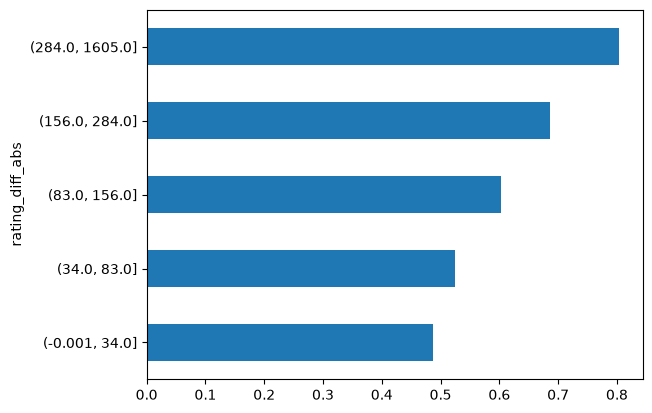

In [33]:
win_rate_by_rating_gap["mean"].plot(kind="barh")

<Axes: ylabel='rating_diff_abs'>

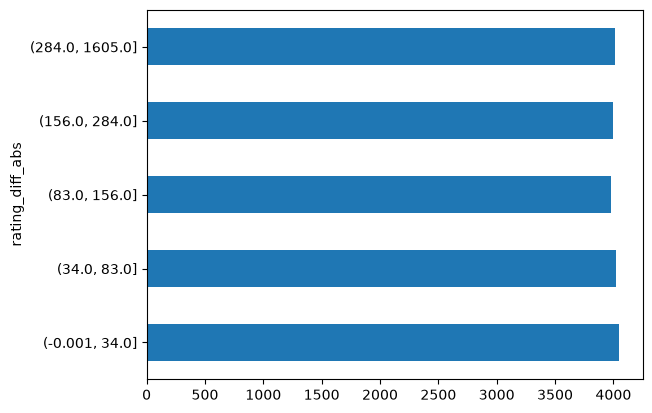

In [34]:
win_rate_by_rating_gap["count"].plot(kind="barh",)

In [35]:
(df['rating_diff_abs'] > 300).mean()

np.float64(0.18202213580616214)

In [36]:
rating_diff_bins

0        (284.0, 1605.0]
1           (34.0, 83.0]
2         (-0.001, 34.0]
3         (-0.001, 34.0]
4           (34.0, 83.0]
              ...       
20053    (284.0, 1605.0]
20054       (34.0, 83.0]
20055       (34.0, 83.0]
20056      (83.0, 156.0]
20057      (83.0, 156.0]
Name: rating_diff_abs, Length: 20058, dtype: category
Categories (5, interval[float64, right]): [(-0.001, 34.0] < (34.0, 83.0] < (83.0, 156.0] < (156.0, 284.0] < (284.0, 1605.0]]

In [37]:
df["victory_status"].unique()

<StringArray>
['outoftime', 'resign', 'mate', 'draw']
Length: 4, dtype: str

In [38]:
pd.crosstab(index= rating_diff_bins, columns=df["victory_status"], normalize="index" )*100

victory_status,draw,mate,outoftime,resign
rating_diff_abs,,,,
"(-0.001, 34.0]",4.841897,30.410079,8.522727,56.225296
"(34.0, 83.0]",5.440994,29.565217,9.515528,55.478261
"(83.0, 156.0]",4.621954,30.419493,8.515448,56.443105
"(156.0, 284.0]",4.406610,32.173260,8.012018,55.408112
"(284.0, 1605.0]",3.266833,35.112219,7.306733,54.314214


In [39]:
df.head()

,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,...,opening_eco,opening_name,opening_ply,base_time,increment,rating_diff,rating_diff_abs,variation,higher_rated_player,higher_rated_won
0,TZJHLljE,False,2017-08-31 20:06:40,2017-08-31 20:06:40,13,outoftime,white,15+2,bourgris,1500,...,D10,Slav Defense,5,15,2,309,309,Exchange Variation,white,True
1,l1NXvwaE,True,2017-08-30 21:53:20,2017-08-30 21:53:20,16,resign,black,5+10,a-00,1322,...,B00,Nimzowitsch Defense,4,5,10,61,61,Kennedy Variation,white,False
2,mIICvQHh,True,2017-08-30 21:53:20,2017-08-30 21:53:20,61,mate,white,5+10,ischia,1496,...,C20,King's Pawn Game,3,5,10,-4,4,Leonardis Variation,black,False
3,kWKvrqYL,True,2017-08-30 16:20:00,2017-08-30 16:20:00,61,mate,white,20+0,daniamurashov,1439,...,D02,Queen's Pawn Game,3,20,0,-15,15,Zukertort Variation,black,False
4,9tXo1AUZ,True,2017-08-29 18:06:40,2017-08-29 18:06:40,95,mate,white,30+3,nik221107,1523,...,C41,Philidor Defense,5,30,3,54,54,NaN,white,True


In [40]:
df["opening_ply"].corr(df["turns"])

np.float64(0.05599876874489277)

C:\Users\BURAIR\AppData\Local\Temp\ipykernel_15848\2572736705.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["opening_ply"])


<Axes: xlabel='opening_ply', ylabel='Density'>

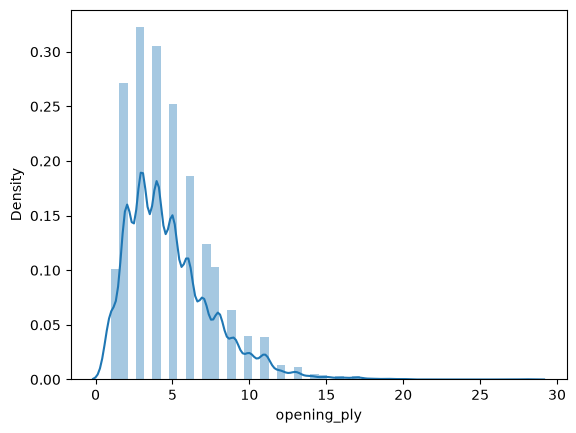

In [41]:
sns.distplot(df["opening_ply"])

In [42]:
df['opening_ply_bucket'] = pd.qcut(df['opening_ply'], q=5)

In [43]:
pd.crosstab(index = df["opening_ply_bucket"], columns=df["victory_status"], normalize="index")

victory_status,draw,mate,outoftime,resign
opening_ply_bucket,,,,
"(0.999, 2.0]",0.044891,0.345982,0.093254,0.515873
"(2.0, 4.0]",0.042218,0.340541,0.085172,0.532068
"(4.0, 5.0]",0.046154,0.304762,0.084982,0.564103
"(5.0, 7.0]",0.042806,0.298454,0.074019,0.584721
"(7.0, 28.0]",0.053606,0.248564,0.077856,0.619974


In [44]:
df["opening_name"].value_counts()

opening_name
Sicilian Defense                                                   2573
French Defense                                                     1306
Queen's Pawn Game                                                  1059
Italian Game                                                        981
King's Pawn Game                                                    917
                                                                   ... 
King's Gambit Accepted |  Rosentreter-Testa Gambit                    1
King's Gambit Accepted |  Kieseritzky Gambit |  Kolisch Defense       1
King's Gambit Accepted |  Salvio Gambit                               1
King's Gambit Accepted |  Ghulam-Kassim Gambit                        1
King's Gambit |  Falkbeer Countergambit |  Miles Gambit               1
Name: count, Length: 227, dtype: int64

In [45]:
df.head(20)

,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,...,opening_name,opening_ply,base_time,increment,rating_diff,rating_diff_abs,variation,higher_rated_player,higher_rated_won,opening_ply_bucket
0,TZJHLljE,False,2017-08-31 20:06:40,2017-08-31 20:06:40,13,outoftime,white,15+2,bourgris,1500,...,Slav Defense,5,15,2,309,309,Exchange Variation,white,True,"(4.0, 5.0]"
1,l1NXvwaE,True,2017-08-30 21:53:20,2017-08-30 21:53:20,16,resign,black,5+10,a-00,1322,...,Nimzowitsch Defense,4,5,10,61,61,Kennedy Variation,white,False,"(2.0, 4.0]"
2,mIICvQHh,True,2017-08-30 21:53:20,2017-08-30 21:53:20,61,mate,white,5+10,ischia,1496,...,King's Pawn Game,3,5,10,-4,4,Leonardis Variation,black,False,"(2.0, 4.0]"
3,kWKvrqYL,True,2017-08-30 16:20:00,2017-08-30 16:20:00,61,mate,white,20+0,daniamurashov,1439,...,Queen's Pawn Game,3,20,0,-15,15,Zukertort Variation,black,False,"(2.0, 4.0]"
4,9tXo1AUZ,True,2017-08-29 18:06:40,2017-08-29 18:06:40,95,mate,white,30+3,nik221107,1523,...,Philidor Defense,5,30,3,54,54,NaN,white,True,"(4.0, 5.0]"
5,MsoDV9wj,False,2017-09-01 04:26:40,2017-09-01 04:26:40,5,draw,draw,10+0,trelynn17,1250,...,Sicilian Defense,4,10,0,248,248,Mongoose Variation,white,False,"(2.0, 4.0]"
6,qwU9rasv,True,2017-09-01 01:40:00,2017-09-01 01:40:00,33,resign,white,10+0,capa_jr,1520,...,Blackmar-Diemer Gambit,10,10,0,97,97,Pietrowsky Defense,white,True,"(7.0, 28.0]"
7,RVN0N3VK,False,2017-08-25 16:53:20,2017-08-25 16:53:20,9,resign,black,15+30,daniel_likes_chess,1413,...,Nimzowitsch Defense,5,15,30,-695,695,Kennedy Variation | Linksspringer Variation,black,True,"(4.0, 5.0]"
8,dwF3DJHO,True,2017-08-23 17:40:00,2017-08-23 17:40:00,66,resign,black,15+0,ehabfanri,1439,...,Italian Game,6,15,0,47,47,Schilling-Kostic Gambit,white,False,"(5.0, 7.0]"
9,afoMwnLg,True,2017-08-22 22:13:20,2017-08-22 22:13:20,119,mate,white,10+0,daniel_likes_chess,1381,...,Scandinavian Defense,4,10,0,172,172,Mieses-Kotroc Variation,white,True,"(2.0, 4.0]"


In [46]:
df["opening_name"].value_counts()

opening_name
Sicilian Defense                                                   2573
French Defense                                                     1306
Queen's Pawn Game                                                  1059
Italian Game                                                        981
King's Pawn Game                                                    917
                                                                   ... 
King's Gambit Accepted |  Rosentreter-Testa Gambit                    1
King's Gambit Accepted |  Kieseritzky Gambit |  Kolisch Defense       1
King's Gambit Accepted |  Salvio Gambit                               1
King's Gambit Accepted |  Ghulam-Kassim Gambit                        1
King's Gambit |  Falkbeer Countergambit |  Miles Gambit               1
Name: count, Length: 227, dtype: int64

In [47]:
opening_winrate = df.groupby(["opening_name","variation", "winner"]).size().unstack(fill_value = 0)
opening_winrate

opening_winrate["Games"] = opening_winrate.sum(axis=1)
opening_winrate = opening_winrate[opening_winrate["Games"] >= 20]

opening_winrate["white_winrate"] = (opening_winrate["white"]/opening_winrate["Games"]) * 100
opening_winrate["black_winrate"] =(opening_winrate["black"]/opening_winrate["Games"]) * 100
opening_winrate["draw_rate"] =(opening_winrate["draw"]/opening_winrate["Games"]) * 100


opening_winrate.sort_values(by = "Games", ascending=False)


winner                                                      black  draw  \
opening_name         variation                                            
Sicilian Defense     Bowdler Attack                           164    13   
French Defense       Knight Variation                         121    15   
Scandinavian Defense Mieses-Kotroc Variation                   89     6   
Queen's Pawn Game    Mason Attack                             103    13   
                     Chigorin Variation                       109     8   
...                                                           ...   ...   
Indian Game          London System                             13     1   
Ruy Lopez            Morphy Defense |  Tarrasch Variation      13     1   
                     Berlin Defense |  Rio Gambit Accepted      9     2   
Queen's Pawn Game    Steinitz Countergambit                     6     4   
Sicilian Defense     Kan Variation |  Knight Variation         11     0   

winner                                                      white  Games  \
opening_name         variation                                             
Sicilian Defense     Bowdler Attack                           119    296   
French Defense       Knight Variation                         135    271   
Scandinavian Defense Mieses-Kotroc Variation                  164    259   
Queen's Pawn Game    Mason Attack                             116    232   
                     Chigorin Variation                       112    229   
...                                                           ...    ...   
Indian Game          London System                              6     20   
Ruy Lopez            Morphy Defense |  Tarrasch Variation       6     20   
                     Berlin Defense |  Rio Gambit Accepted      9     20   
Queen's Pawn Game    Steinitz Countergambit                    10     20   
Sicilian Defense     Kan Variation |  Knight Variation          9     20   

winner                                                      white_winrate  \
opening_name         variation                                              
Sicilian Defense     Bowdler Attack                             40.202703   
French Defense       Knight Variation                           49.815498   
Scandinavian Defense Mieses-Kotroc Variation                    63.320463   
Queen's Pawn Game    Mason Attack                               50.000000   
                     Chigorin Variation                         48.908297   
...                                                                   ...   
Indian Game          London System                              30.000000   
Ruy Lopez            Morphy Defense |  Tarrasch Variation       30.000000   
                     Berlin Defense |  Rio Gambit Accepted      45.000000   
Queen's Pawn Game    Steinitz Countergambit                     50.000000   
Sicilian Defense     Kan Variation |  Knight Variation          45.000000   

winner                                                      black_winrate  \
opening_name         variation                                              
Sicilian Defense     Bowdler Attack                             55.405405   
French Defense       Knight Variation                           44.649446   
Scandinavian Defense Mieses-Kotroc Variation                    34.362934   
Queen's Pawn Game    Mason Attack                               44.396552   
                     Chigorin Variation                         47.598253   
...                                                                   ...   
Indian Game          London System                              65.000000   
Ruy Lopez            Morphy Defense |  Tarrasch Variation       65.000000   
                     Berlin Defense |  Rio Gambit Accepted      45.000000   
Queen's Pawn Game    Steinitz Countergambit                     30.000000   
Sicilian Defense     Kan Variation |  Knight Variation          55.000000   

winner                         

In [48]:
opening_winrate = opening_winrate[opening_winrate["Games"] >= 30]
opening_winrate.sort_values(by = ["white_winrate","Games"], ascending=False)

,winner,black,draw,white,Games,white_winrate,black_winrate,draw_rate
opening_name,variation,,,,,,,
Russian Game,Damiano Variation,8,0,32,40,80.000000,20.000000,0.000000
Zukertort Opening,Queen's Gambit Invitation,13,3,37,53,69.811321,24.528302,5.660377
French Defense,Advance Variation #3,13,0,29,42,69.047619,30.952381,0.000000
English Opening,Agincourt Defense,8,2,21,31,67.741935,25.806452,6.451613
Ruy Lopez,Morphy Defense | Caro Variation,11,2,27,40,67.500000,27.500000,5.000000
...,...,...,...,...,...,...,...,...
French Defense,Advance Variation | Nimzowitsch System,23,2,13,38,34.210526,60.526316,5.263158
Italian Game,Schilling-Kostic Gambit,25,3,13,41,31.707317,60.975610,7.317073
French Defense,King's Indian Attack,22,0,10,32,31.250000,68.750000,0.000000


In [49]:
win_rate_by_rating_gap

,mean,count
rating_diff_abs,,
"(-0.001, 34.0]",0.487401,4048
"(34.0, 83.0]",0.524472,4025
"(83.0, 156.0]",0.602864,3981
"(156.0, 284.0]",0.686279,3994
"(284.0, 1605.0]",0.803491,4010


In [50]:
rated_only = df[df["rated"] == True] 
unrated_only = df[df["rated"] == False] 

In [51]:
rated_win_rate_comparison = df.groupby([rating_diff_bins, "rated"])["higher_rated_won"].agg(["mean", "count"])

In [52]:
rated_win_rate_comparison

mean  count
rating_diff_abs rated                 
(-0.001, 34.0]  False  0.485714    525
                True   0.487653   3523
(34.0, 83.0]    False  0.508946    503
                True   0.526689   3522
(83.0, 156.0]   False  0.581498    681
                True   0.607273   3300
(156.0, 284.0]  False  0.639019    856
                True   0.699171   3138
(284.0, 1605.0] False  0.735426   1338
                True   0.837575   2672

<Axes: ylabel='rating_diff_abs,rated'>

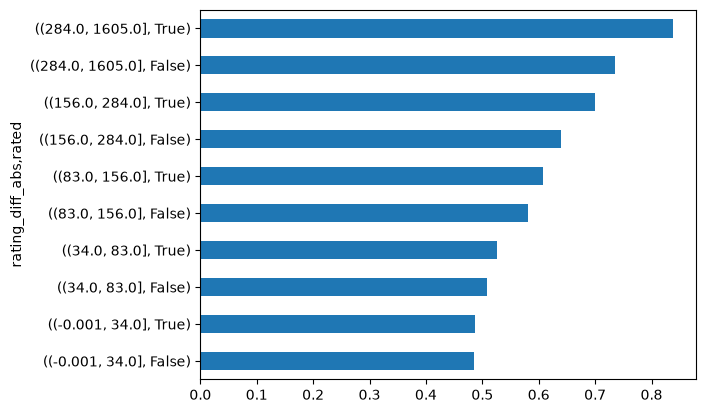

In [53]:
rated_win_rate_comparison["mean"].plot(kind="barh")

In [54]:
counts = df.groupby(["rated", "victory_status"]).size().unstack(fill_value=0)
percentages = counts.div(counts.sum(axis=1), axis=0) * 100

percentages


victory_status,draw,mate,outoftime,resign
rated,,,,
False,5.764796,30.207533,8.224443,55.803228
True,4.215413,31.853915,8.412256,55.518415


In [55]:
turns_v_rated = df.groupby(["rated"])["turns"].describe()
turns_v_rated

,count,mean,std,min,25%,50%,75%,max
rated,,,,,,,,
False,3903.0,54.271586,32.162533,1.0,31.0,50.0,72.0,206.0
True,16155.0,61.962550,33.732775,1.0,39.0,57.0,80.0,349.0


# Phase 4 — Findings & Recommendation



In [56]:
df

,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,...,opening_name,opening_ply,base_time,increment,rating_diff,rating_diff_abs,variation,higher_rated_player,higher_rated_won,opening_ply_bucket
0,TZJHLljE,False,2017-08-31 20:06:40.000,2017-08-31 20:06:40.000,13,outoftime,white,15+2,bourgris,1500,...,Slav Defense,5,15,2,309,309,Exchange Variation,white,True,"(4.0, 5.0]"
1,l1NXvwaE,True,2017-08-30 21:53:20.000,2017-08-30 21:53:20.000,16,resign,black,5+10,a-00,1322,...,Nimzowitsch Defense,4,5,10,61,61,Kennedy Variation,white,False,"(2.0, 4.0]"
2,mIICvQHh,True,2017-08-30 21:53:20.000,2017-08-30 21:53:20.000,61,mate,white,5+10,ischia,1496,...,King's Pawn Game,3,5,10,-4,4,Leonardis Variation,black,False,"(2.0, 4.0]"
3,kWKvrqYL,True,2017-08-30 16:20:00.000,2017-08-30 16:20:00.000,61,mate,white,20+0,daniamurashov,1439,...,Queen's Pawn Game,3,20,0,-15,15,Zukertort Variation,black,False,"(2.0, 4.0]"
4,9tXo1AUZ,True,2017-08-29 18:06:40.000,2017-08-29 18:06:40.000,95,mate,white,30+3,nik221107,1523,...,Philidor Defense,5,30,3,54,54,NaN,white,True,"(4.0, 5.0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20053,EfqH7VVH,True,2017-07-11 16:35:14.342,2017-07-11 16:40:36.076,24,resign,white,10+10,belcolt,1691,...,Dutch Defense,2,10,10,471,471,NaN,white,True,"(0.999, 2.0]"
20054,WSJDhbPl,True,2017-07-10 14:48:09.760,2017-07-10 15:00:33.979,82,mate,black,10+0,jamboger,1233,...,Queen's Pawn,2,10,0,37,37,NaN,white,False,"(0.999, 2.0]"
20055,yrAas0Kj,True,2017-07-10 14:44:37.493,2017-07-10 14:47:30.327,35,mate,white,10+0,jamboger,1219,...,Queen's Pawn Game,3,10,0,-67,67,Mason Attack,black,False,"(2.0, 4.0]"
20056,b0v4tRyF,True,2017-07-10 14:15:27.019,2017-07-10 14:31:13.718,109,resign,white,10+0,marcodisogno,1360,...,Pirc Defense,4,10,0,133,133,NaN,white,True,"(2.0, 4.0]"


In [57]:
sns.set_theme(style="darkgrid")

<Axes: ylabel='rated'>

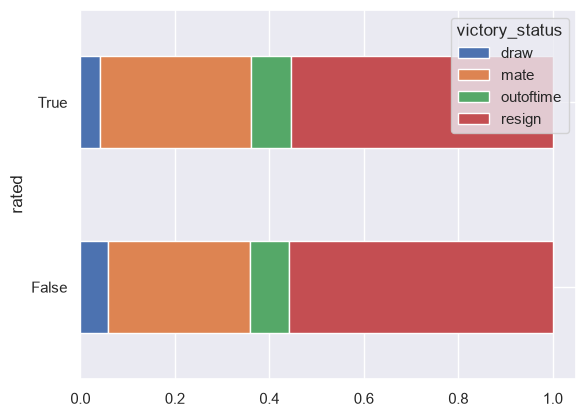

In [58]:
# Relationship Between Rated Vs Unrated in How Games End
sns.set_theme(style="darkgrid")

pd.crosstab(index=df["rated"], columns=df["victory_status"], normalize="index").plot(kind="barh", stacked=True)


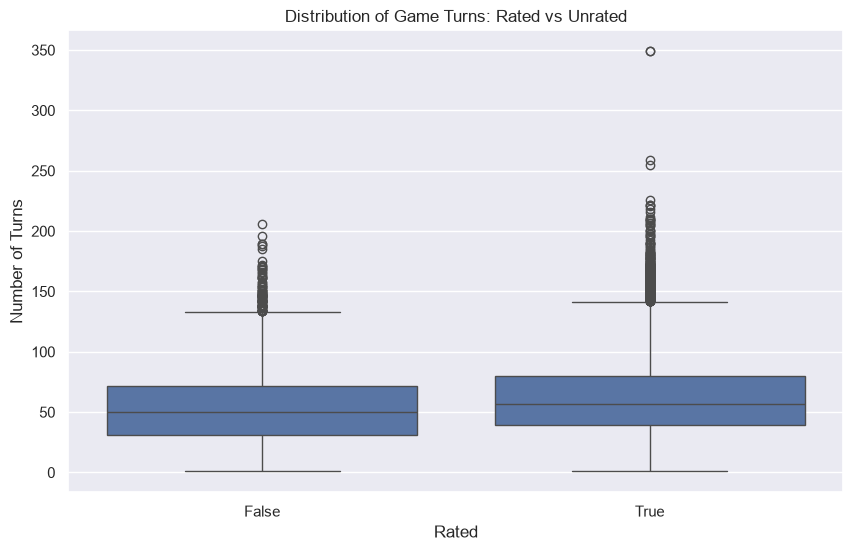

In [59]:
turns_v_rated

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="rated", y="turns")
plt.xlabel("Rated")
plt.ylabel("Number of Turns")
plt.title("Distribution of Game Turns: Rated vs Unrated")
plt.show()

This project is best understood as a **platform analytics exercise about matchmaking quality and player experience**, not as a generic chess EDA. 
From the perspective of a data analyst at Lichess, the questions that matter are product questions: does the rating system produce fair matchups, 
does a rating gap reliably predict who wins, and where does matchmaking break down? 
The core spine question is whether rating difference is a dependable predictor of game outcome — and where that relationship weakens or fails. 
Everything below reads the data through that lens: matchmaking quality is the outcome of interest, and game-level features (how games end, how long they run, 
which openings get played) are treated as signals about the player experience those matchups create.


In [60]:
findings_summary = win_rate_by_rating_gap.copy()
findings_summary["share_of_games"] = findings_summary["count"] / len(df) * 100
findings_summary = findings_summary.rename(columns={"mean": "favorite_win_rate", "count": "games"})
findings_summary


,favorite_win_rate,games,share_of_games
rating_diff_abs,,,
"(-0.001, 34.0]",0.487401,4048,20.181474
"(34.0, 83.0]",0.524472,4025,20.066806
"(83.0, 156.0]",0.602864,3981,19.847442
"(156.0, 284.0]",0.686279,3994,19.912254
"(284.0, 1605.0]",0.803491,4010,19.992023


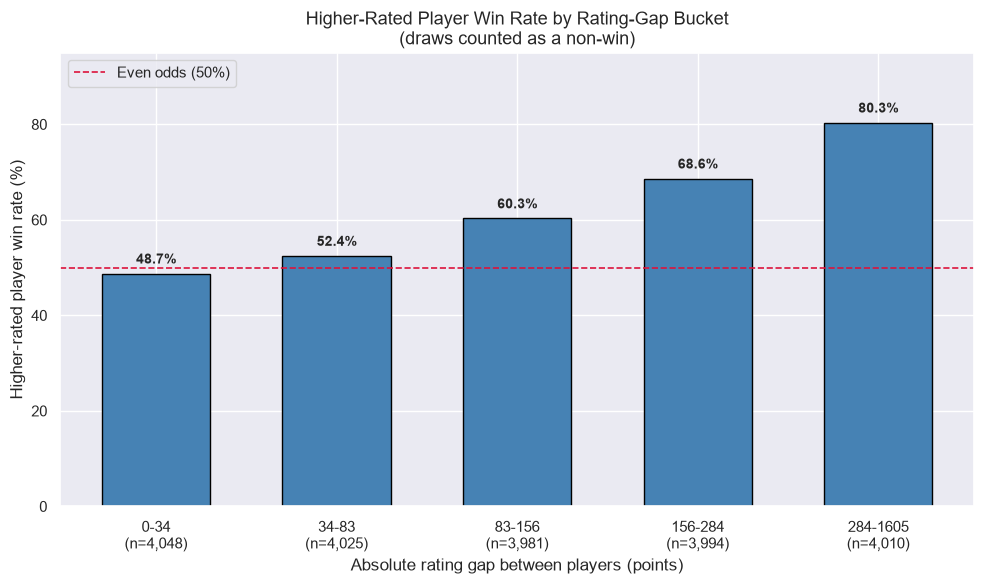

In [61]:
fig, ax = plt.subplots(figsize=(10, 6))

rates = win_rate_by_rating_gap["mean"] * 100
counts = win_rate_by_rating_gap["count"]


def bucket_label(interval):
    lo = max(0, interval.left)
    return f"{lo:.0f}-{interval.right:.0f}"


labels = [f"{bucket_label(it)}\n(n={c:,})" for it, c in zip(win_rate_by_rating_gap.index, counts)]

ax.bar(labels, rates, color="steelblue", edgecolor="black", width=0.6)
for i, r in enumerate(rates):
    ax.text(i, r + 1.5, f"{r:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.axhline(50, color="crimson", linestyle="--", linewidth=1.2, label="Even odds (50%)")
ax.set_ylim(0, 95)
ax.set_xlabel("Absolute rating gap between players (points)")
ax.set_ylabel("Higher-rated player win rate (%)")
ax.set_title("Higher-Rated Player Win Rate by Rating-Gap Bucket\n(draws counted as a non-win)", fontsize=13)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


### Findings

**1. Rating gap is a strong, monotonic predictor of outcome — but close games are genuinely competitive.** 
Higher-rated players win just 48.7% of games when the gap is within 34 points, rising steadily to 80.3% when the gap exceeds 284 points 
(quintile buckets, roughly 4,000 games each; summary table and chart above). 
*So what:* the matchmaker behaves the way an Elo system should — outcomes become more lopsided as mismatch grows — while tight matches stay near coin-flips, 
which is a healthy sign for competitive play. The real design risk sits in the tail, not in the middle bands.

**2. A real mismatch tail exists: roughly 1 in 5 games is effectively pre-decided.** 
18.2% of all games are played with a rating gap above 300 points, and in the widest quintile (284+ points) the higher-rated player wins 80.3% of the time. 
*So what:* the platform should monitor whether that tail is driven by matchmaking-queue necessity (off-peak hours, thin rating bands, 
new-account rating variance) rather than being an intentional feature of the ladder.

**3. Mismatch changes who wins, not how games end.** 
The victory_status mix is almost flat across rating-gap buckets: checkmate endings rise modestly from 30.4% to 35.1%, 
out-of-time endings dip from 8.5% to 7.3%, and resignation stays the dominant outcome (~55-56%) in every bucket. 
*So what:* imbalanced matchups do not produce visibly "broken" or abandoned games — their cost shows up as predictable, frustrating losses 
rather than anomalous game flow, which is a retention risk that outcome balance alone won't surface.

**4. Rated games are more predictable and slightly longer.** 
The higher-rated player wins 83.8% of rated games versus 73.5% of unrated games in the widest gap bucket, 
and rated games average 62.0 turns versus 54.3 for unrated (medians 57 vs 50). 
*So what:* unrated play is a lower-commitment, noisier environment; keeping both populations in the analysis is defensible, 
but matchmaking-quality monitoring should weight rated games more heavily.

**5. Openings: book depth is barely tied to game length, but variation win rates show large — and as-yet unvalidated — spreads.** 
The correlation between opening_ply and turns is very weak (0.056), yet games that go deeper into book end more often in resignation (51.6% → 62.0%) 
and less often in mate (34.6% → 24.9%). In the opening/variation table, white win rates range from 80.0% 
(Russian Game: Damiano Variation, 40 games) down to 30.0% (Sicilian Defense: Modern Variations Main Line, 30 games). 
*So what:* the variation win-rate spread is the most product-relevant lead here — it is the natural basis for a 
"which lines work against this opening" feature — but the small samples make these candidates for validation rather than confirmed effects.


### Limitations

Four caveats apply to this write-up. First, `created_at` and `last_move_at` are identical for ~43% of rows even though many of those games run 
dozens of turns, which points to a low-precision timestamp collection artifact rather than instant games; the analysis therefore never treats 
timestamp deltas as a measure of game duration. Second, the `higher_rated_won` metric counts a draw as "the favorite did not win," 
a deliberate simplification that keeps the interpretation clean but slightly understates how often the favorite avoids losing. 
Third, the opening/variation win-rate table is filtered to variations with at least 30 games, and many entries sit right at that threshold; 
results near the cutoff should be read as directional candidates for further investigation, and only rows with 100+ games should be treated as reliable. 
Finally, this dataset contains no session, churn, or retention data, so any claims about player experience are inferred from proxies 
(game length, resignation behavior, outcome predictability) rather than directly measured.
